# Tumor patch classification

This notebook reads what the pipeline recorded. It trains nothing. Run `python analysis/run_all.py` first.

The task is to decide whether a 32 by 32 patch of an axial T1 post-contrast slice lies inside the tumor.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
from IPython.display import Image, display

from src import config
from src.s99_utils import Metrics

pd.set_option("display.width", 110)
pd.set_option("display.max_rows", 60)

metrics = Metrics()


def table(name):
    return pd.read_csv(config.RESULTS / (name + ".csv"))


def figure(name):
    display(Image(filename=str(config.FIGURES / name)))


## The patch set

Tumor occupies a small part of the brain, so patches sampled on a regular grid are overwhelmingly negative. Negatives are subsampled to a fixed ratio for each patient, and the rate before sampling is kept so that the design choice stays visible.

In [2]:
summary = table("patch_summary")
print("patches", int(metrics.number("patches_total")),
      "of which positive", int(metrics.number("patches_positive")))
print("median positive rate before sampling: {:.4f}".format(
      metrics.number("patches_natural_positive_rate_median")))
summary[["patient_id", "slices_with_tumor", "tumor_fraction_of_brain",
         "candidate_positive_patches", "natural_positive_rate",
         "patches_positive", "patches_negative"]].head(10)

patches 48537 of which positive 16179
median positive rate before sampling: 0.0200


,patient_id,slices_with_tumor,tumor_fraction_of_brain,candidate_positive_patches,natural_positive_rate,patches_positive,patches_negative
0,UPENN-GBM-00019,51,0.026330,608,0.020044,500,1000
1,UPENN-GBM-00020,50,0.013369,304,0.007673,304,608
2,UPENN-GBM-00032,74,0.051787,1846,0.043546,500,1000
3,UPENN-GBM-00048,83,0.061097,2055,0.058430,500,1000
4,UPENN-GBM-00049,50,0.017462,388,0.009861,388,776
5,UPENN-GBM-00050,33,0.004667,36,0.000851,36,72
6,UPENN-GBM-00062,60,0.025427,626,0.017909,500,1000
7,UPENN-GBM-00075,47,0.014733,280,0.008381,280,560
8,UPENN-GBM-00085,55,0.024520,640,0.018600,500,1000
9,UPENN-GBM-00101,68,0.031644,795,0.024402,500,1000


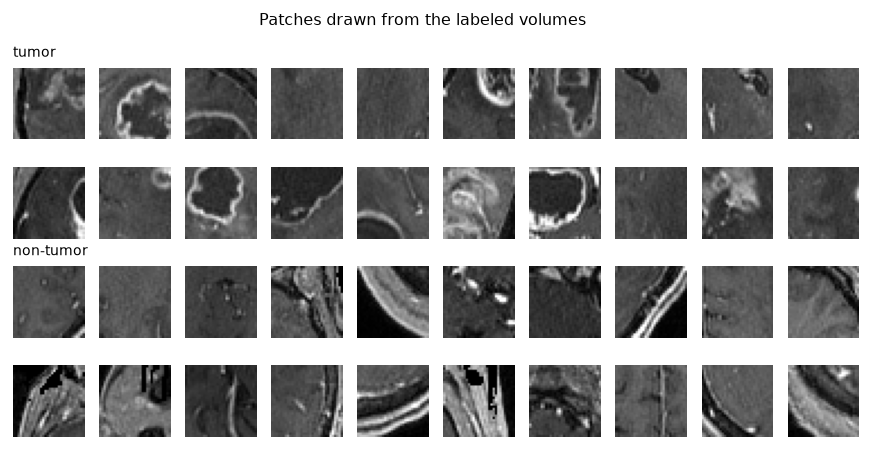

In [3]:
figure("fig05_patch_examples.png")

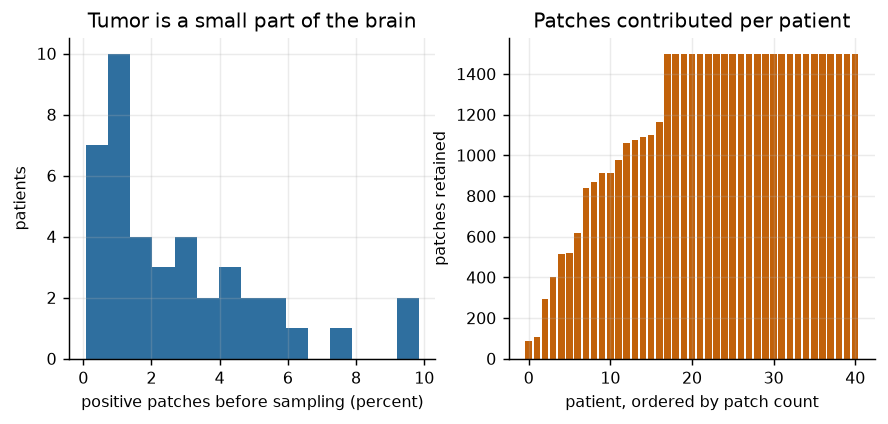

In [4]:
figure("fig06_class_balance.png")

## The split

Patches are cut on an eight pixel stride, so neighboring patches overlap by three quarters of their area. Splitting over patches would put near copies of the same tissue on both sides of the boundary. Whole patients are assigned instead.

In [5]:
splits = table("splits")
splits.groupby("split").agg(patients=("patient_id", "size"),
                            patches=("patches", "sum"),
                            positive=("positive", "sum"))

,patients,patches,positive
split,,,
test,10,10452,3484
train,25,30294,10098
validation,6,7791,2597


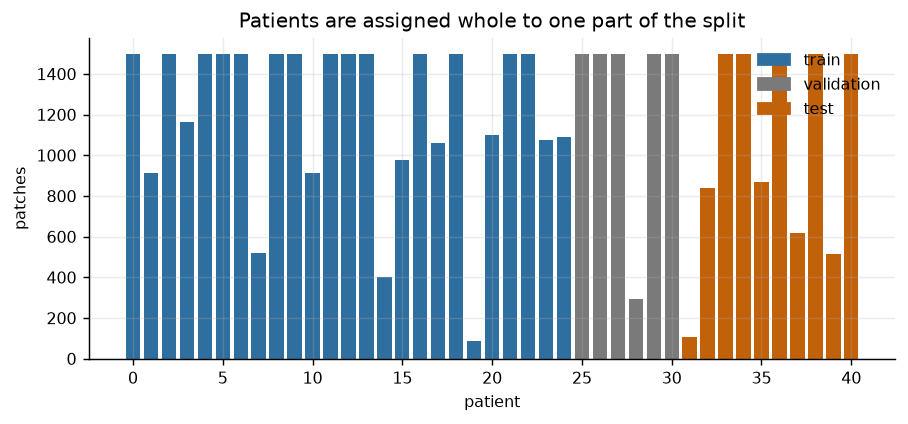

In [6]:
figure("fig07_splits.png")

## Grid search

Every combination is scored on the validation patients, who appear in neither the training nor the test set.

In [7]:
table("model_grid")

,learning_rate,dropout,epochs,validation_roc_auc_final,validation_roc_auc_best,train_loss_final,seconds
0,1.0,0.5,8,0.9723,0.9755,0.0730,132.7
1,0.1,0.5,8,0.9388,0.9545,0.1206,127.9
2,0.1,0.3,8,0.9344,0.9631,0.0997,142.5
3,1.0,0.3,8,0.9308,0.9771,0.0545,145.0


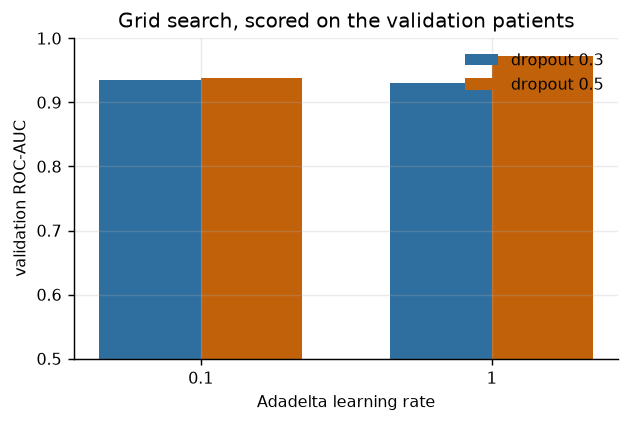

In [8]:
figure("fig08_grid_search.png")

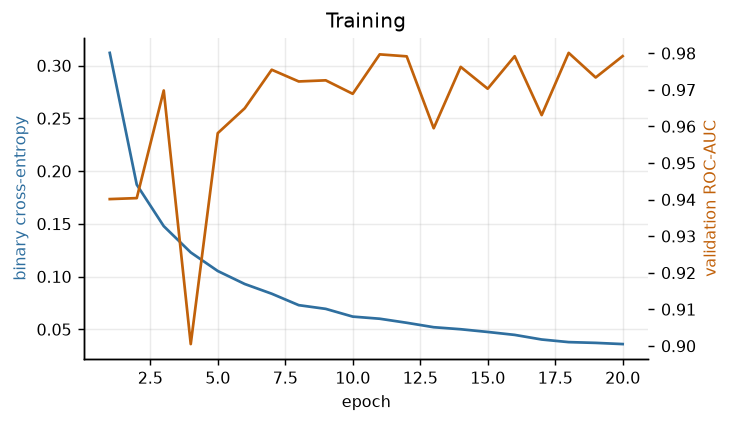

In [9]:
figure("fig09_training_history.png")

## Results on the held-out patients

In [10]:
rows = []
for part in ("train", "validation", "test"):
    rows.append({
        "split": part,
        "patches": int(metrics.number("eval_" + part + "_patches")),
        "roc_auc": metrics.number("eval_" + part + "_roc_auc"),
        "accuracy": metrics.number("eval_" + part + "_accuracy"),
    })
pd.DataFrame(rows)

,split,patches,roc_auc,accuracy
0,train,30294,0.9999,0.9917
1,validation,7791,0.9792,0.9153
2,test,10452,0.9731,0.8859


In [11]:
table("classification_report")

,split,class,precision,recall,f1,support
0,train,non-tumor,0.9883,0.9994,0.9938,20196
1,train,tumor,0.9988,0.9763,0.9874,10098
2,validation,non-tumor,0.8928,0.9921,0.9398,5194
3,validation,tumor,0.9797,0.7616,0.8570,2597
4,test,non-tumor,0.8556,0.9970,0.9209,6968
5,test,tumor,0.9910,0.6636,0.7949,3484


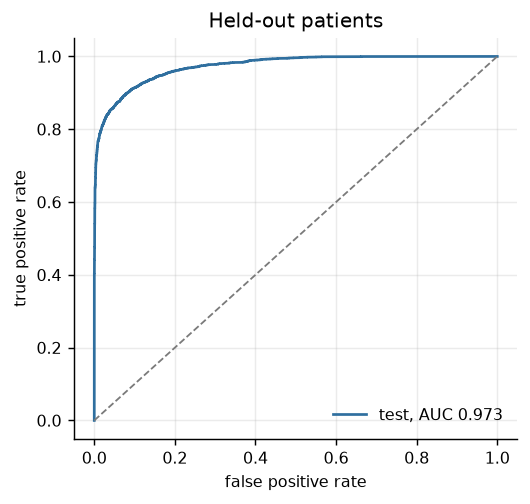

In [12]:
figure("fig10_roc_test.png")

In [13]:
confusion = table("confusion_matrix")
confusion[confusion["split"] == "test"].pivot(
    index="actual", columns="predicted", values="count")

predicted,non-tumor,tumor
actual,,
non-tumor,6947,21
tumor,1172,2312


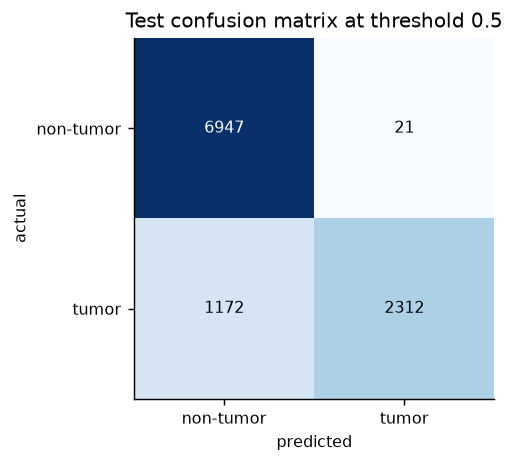

In [14]:
figure("fig11_confusion_matrix.png")

## Where the model fails

A score pooled over patches hides a model that works on most patients and fails on a few, so the test set is broken down by patient.

In [15]:
table("per_patient_test").sort_values("roc_auc").head(10)

,patient_id,patches,positive_rate,roc_auc,accuracy,false_positive,false_negative
9,UPENN-GBM-00518,1500,0.3333,0.9361,0.8067,5,285
5,UPENN-GBM-00338,1500,0.3333,0.9447,0.8213,3,265
1,UPENN-GBM-00075,840,0.3333,0.9740,0.8393,0,135
8,UPENN-GBM-00438,516,0.3333,0.9781,0.6977,1,155
4,UPENN-GBM-00264,870,0.3333,0.9804,0.8954,1,90
2,UPENN-GBM-00142,1500,0.3333,0.9825,0.9527,3,68
7,UPENN-GBM-00409,1500,0.3333,0.9936,0.9067,3,137
3,UPENN-GBM-00226,1500,0.3333,0.9988,0.9833,3,22
6,UPENN-GBM-00397,618,0.3333,0.9989,0.9757,0,15
0,UPENN-GBM-00050,108,0.3333,1.0000,0.9815,2,0


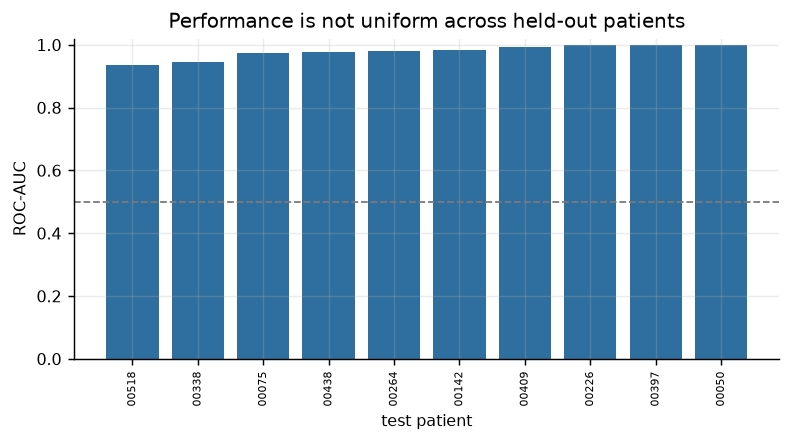

In [16]:
figure("fig12_per_patient.png")

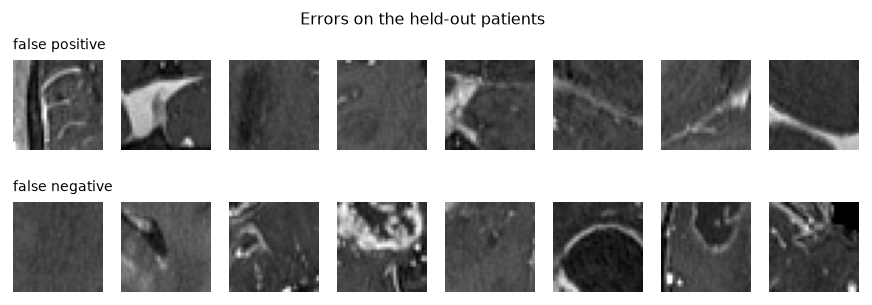

In [17]:
figure("fig14_errors.png")

## What splitting over patches would have reported

The same architecture and the same hyperparameters, trained on a partition that shuffles patches instead of patients.

In [18]:
pd.Series({
    "test ROC-AUC, split by patient":
        metrics.number("leakage_test_roc_auc_patient_split"),
    "test ROC-AUC, split by patch":
        metrics.number("leakage_test_roc_auc_patch_split"),
    "difference": metrics.number("leakage_roc_auc_inflation"),
}).to_frame("value")

,value
"test ROC-AUC, split by patient",0.9731
"test ROC-AUC, split by patch",0.9929
difference,0.0199


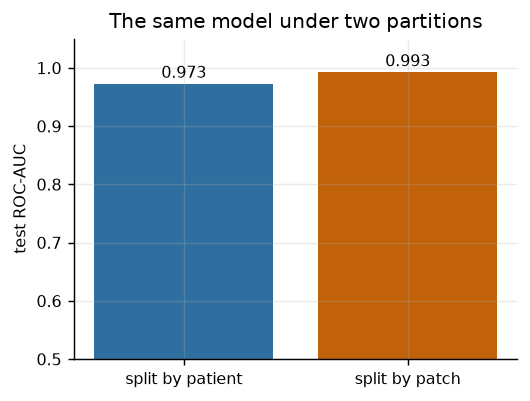

In [19]:
figure("fig13_split_leakage.png")